In [ ]:
import sys
import networkx as nx
import osmnx as ox
import matplotlib.pyplot as plt
from collections import defaultdict
from collections import Counter

#NOTE by default OSM doesnt call the bicycle and cycleway info for performance reasons  
ox.settings.useful_tags_way = ox.settings.useful_tags_way + ["bicycle", "cycleway"]

bike


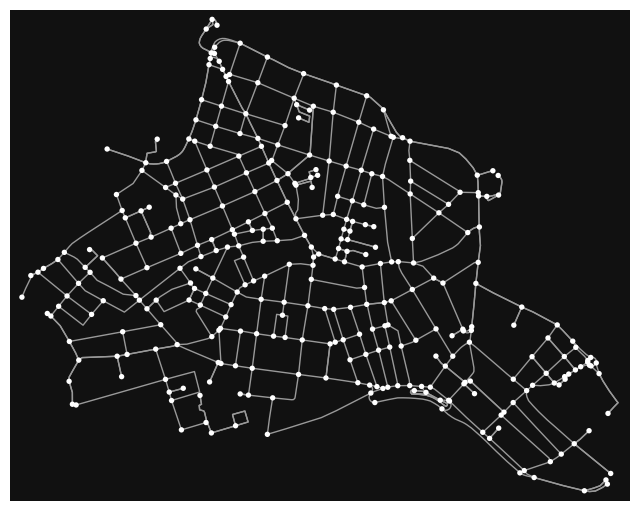

drive


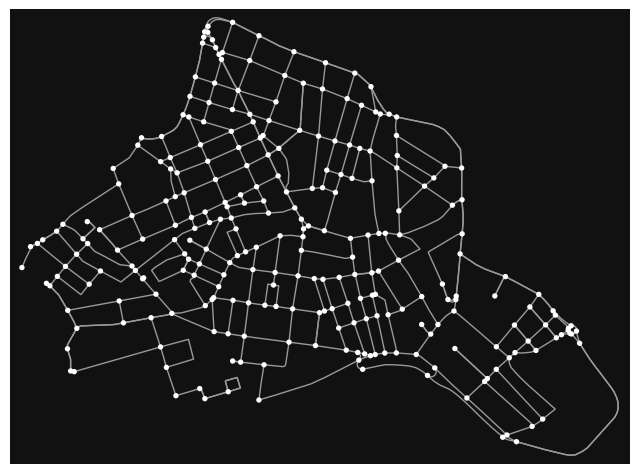

In [3]:
print("bike")

# download/model a street network for some city then visualize it
G = ox.graph.graph_from_place("Sliema, Malta", network_type="bike")
fig, ax = ox.plot.plot_graph(G)

print("drive")
# download/model a street network for some city then visualize it
G = ox.graph.graph_from_place("Sliema, Malta", network_type="drive")
fig, ax = ox.plot.plot_graph(G)

OSM Highway Tags Reference


Motor Vehicle Roads


- residential (26,195) - Streets in residential areas, usually low speed
- unclassified (6,501) - Minor public roads, often rural or local streets
- tertiary (5,268) - Important local roads connecting towns/villages
- secondary (4,327) - Regional roads connecting cities/large towns
- primary (1,624) - Major roads between cities, often dual carriageway
- trunk (1,378) - Major highways, national importance roads


Service & Access Roads
- service (15,417) - Service roads (parking lots, driveways, alleys)
- trunk_link (209) - Connecting ramps to trunk roads
- secondary_link (65) - Connecting ramps to secondary roads
- tertiary_link (43) - Connecting ramps to tertiary roads
- primary_link (39) - Connecting ramps to primary roads


Pedestrian & Cycling Infrastructure
- track (11,050) - Tracks for agriculture/forestry, often unpaved
- path (2,408) - Generic paths for walking/cycling
- living_street (1,040) - Shared space streets (pedestrians have priority)
- pedestrian (564) - Pedestrian-only areas/streets
- cycleway (282) - Dedicated bicycle infrastructure


Public Transport
- busway (1) - Dedicated bus lanes/roads


Road Hierarchy (Malta context)
- Trunk → Main highways
- Primary → Major arterial roads
- Secondary → Important regional roads
- Tertiary → Local connector roads
- Unclassified → Minor local roads
- Residential → Neighborhood streets

Highway type counts:
residential: 27204
service: 18059
track: 11950
footway: 9078
unclassified: 6904
tertiary: 5652
secondary: 4660
path: 2842
primary: 1751
trunk: 1541
steps: 1538
living_street: 1040
pedestrian: 644
cycleway: 399
trunk_link: 259
secondary_link: 67
tertiary_link: 45
primary_link: 45
corridor: 12
busway: 1
-------
bikeway classification type counts:
None: 90015
yes: 2802
designated: 431
no: 367
private: 50
permissive: 16
dismount: 10
------
cycleway type counts:
None: 93401
no: 187
shared: 40
track: 21
lane: 20
shared_lane: 12
crossing: 10


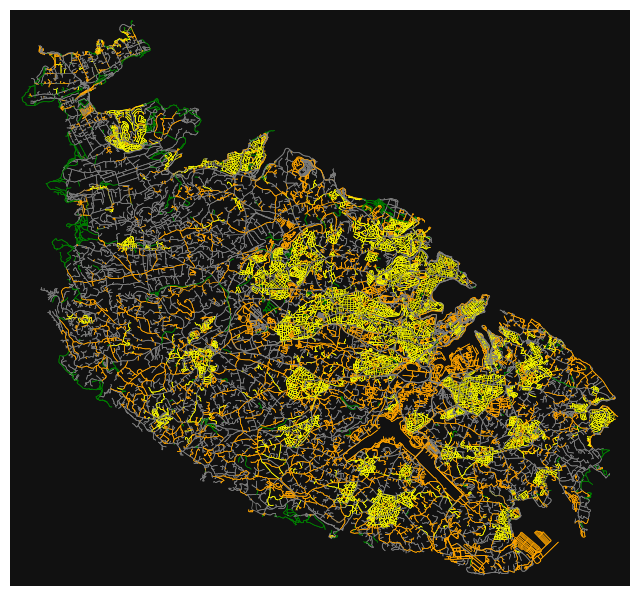

In [ ]:
# download/model a street network for some city then visualize it
from itertools import cycle


G = ox.graph.graph_from_place("Malta (island)", network_type="all")
#fig, ax = ox.plot_graph(G, node_size=0, edge_linewidth=0.5)

highway_color_map = {
    # SAFEST - Dedicated cycling infrastructure
    "cycleway": "green",        # Dedicated bike paths - safest
    "path": "green",           # Shared paths - generally safe
    
    # MODERATE - Cyclist-friendly streets  
    "living_street": "yellow",   # Shared space, pedestrian priority
    "residential": "yellow",        # Low speed, low traffic
    "pedestrian": "yellow",         # Walk/bike only areas

    
    # CAUTION - Mixed traffic but manageable
    "unclassified": "orange",  # Rural/local roads - variable safety
    "service": "orange",         # Parking lots, alleys - usually low speed
    #"track": "orange",            # Unpaved - may not be suitable
}



# Get the color for each edge based on its 'highway' attribute
edge_colors = []
highway_counts = Counter()
bikeway_counts = Counter()
cycleway_counts = Counter()
for u, v, k, data in G.edges(keys=True, data=True):
    once = False

    highway = data.get("highway")
    # Some edges may have a list of highway types
    if isinstance(highway, list): 
        highway = highway[0]

    bicycle = data.get("bicycle")
    # Some edges may have a list of highway types
    if isinstance(bicycle, list):
        bicycle = bicycle[0]

    cycleway = data.get("cycleway")
    # Some edges may have a list of highway types
    if isinstance(cycleway, list): 
        cycleway = cycleway[0]

    # Override dangerous roads if bicycle=yes,
    # example kappara junction there is protected cycle lane on the main road 
    match(bicycle):
        case "designated": colour = "green"
        case "yes": colour = "green"
        case _: color = highway_color_map.get(highway, "gray") 
    edge_colors.append(color)

    highway_counts[highway] += 1
    bikeway_counts[bicycle] += 1
    cycleway_counts[cycleway] += 1

print("Highway type counts:")
for highway_type, count in highway_counts.most_common():
    print(f"{highway_type}: {count}")

print("-------")
print("bikeway classification type counts:")
for bikeway_type, count in bikeway_counts.most_common():
    print(f"{bikeway_type}: {count}")

print("------")
print("cycleway type counts:")
for cycleway_type, count in cycleway_counts.most_common():
    print(f"{cycleway_type}: {count}")


fig, ax = ox.plot_graph(G, node_size=0, edge_color=edge_colors, edge_linewidth=0.5)

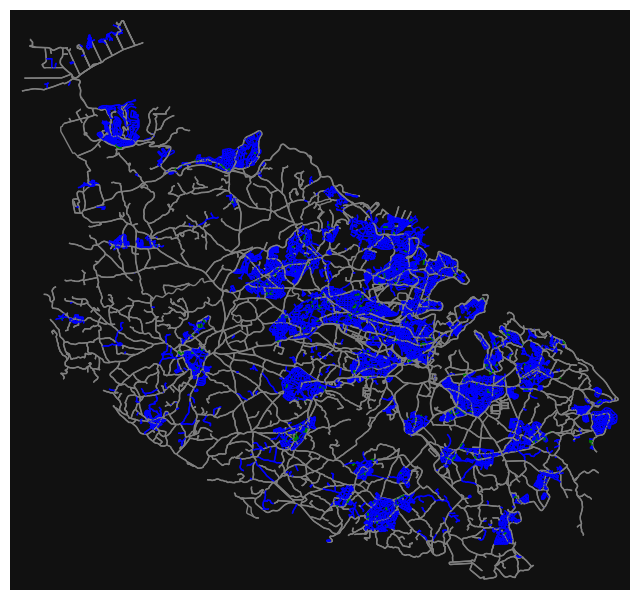

In [5]:
cycleways = '["cycleway"~"lane|track|share_busway|shared_lane"]' # cycleway = infrastructure type (physical/painted features)
highways = '["highway"~"residential|living_street|pedestrian|footway|cycleway"]'

#NOTE There is only 1 cycleway street
#TODO SPEED LIMIT TAG
#TODO painted lane like kapara junction

#bicycles = '["bicycle"!~"no"]' # bicycle = legal access (permission/prohibition), if there is not a tag there is implied service
bicycles = '["bicycle"~"yes|designated"]'
access = '["access"!~"private"]'

cf = f'{bicycles}{access}'

#NOTE Malta (island) vs Malta to exclude Gozo and Comino

G_drive = ox.graph.graph_from_place("Malta (island)", network_type="drive")
G_cycle = ox.graph.graph_from_place("Malta (island)", custom_filter=cf)

G = nx.compose(G_drive,G_cycle)
    
highway_color_map = {
    "residential":"blue",
    "living_street": "green",
    "pedestrian": "orange",
    "footway": "purple",
    "cycleway": "red"
}

# Get the color for each edge based on its 'highway' attribute
edge_colors = []
for u, v, k, data in G.edges(keys=True, data=True):
    highway = data.get("highway")
    # Some edges may have a list of highway types; handle that
    if isinstance(highway, list):
        highway = highway[0]
    color = highway_color_map.get(highway, "gray")  # default to gray if not found
    edge_colors.append(color)

fig, ax = ox.plot_graph(G, node_size=0, edge_color=edge_colors)

# Topology


In [32]:
"""raster_path = "../Data/ebk1km1.tif"
G = ox.elevation.add_node_elevations_raster(G, raster_path, cpus=1)
G = ox.elevation.add_edge_grades(G, add_absolute=True)"""

'raster_path = "../Data/ebk1km1.tif"\nG = ox.elevation.add_node_elevations_raster(G, raster_path, cpus=1)\nG = ox.elevation.add_edge_grades(G, add_absolute=True)'

# Basic street network stats

In [33]:
# what sized area does our network cover in square meters?
G_proj = ox.projection.project_graph(G)
nodes_proj = ox.convert.graph_to_gdfs(G_proj, edges=False)
graph_area_m = nodes_proj.union_all().convex_hull.area
graph_area_m

275524219.5147742

In [34]:
# show some basic stats about the network
ox.stats.basic_stats(G_proj, area=graph_area_m, clean_int_tol=15)

{'n': 15780,
 'm': 35608,
 'k_avg': 4.513054499366286,
 'edge_length_total': 3321904.9589776746,
 'edge_length_avg': 93.29097278638717,
 'streets_per_node_avg': 2.849619771863118,
 'streets_per_node_counts': {0: 0,
  1: 1898,
  2: 216,
  3: 12072,
  4: 1555,
  5: 33,
  6: 6},
 'streets_per_node_proportions': {0: 0.0,
  1: 0.12027883396704689,
  2: 0.013688212927756654,
  3: 0.7650190114068441,
  4: 0.0985424588086185,
  5: 0.002091254752851711,
  6: 0.00038022813688212925},
 'intersection_count': 13882,
 'street_length_total': 1990686.3459606594,
 'street_segment_count': 22527,
 'street_length_avg': 88.36890602213607,
 'circuity_avg': 1.0706844803490096,
 'self_loop_proportion': 0.0010653882008256758,
 'clean_intersection_count': 8625,
 'node_density_km': 57.27264204863792,
 'intersection_density_km': 50.38395544481569,
 'edge_density_km': 12056.671333024307,
 'street_density_km': 7225.086598435731,
 'clean_intersection_density_km': 31.30396309692662}

# Visualize street centrality

In [35]:
# convert graph to line graph so edges become nodes and vice versa
edge_centrality = nx.closeness_centrality(nx.line_graph(G))
nx.set_edge_attributes(G, edge_centrality, "edge_centrality")

KeyboardInterrupt: 

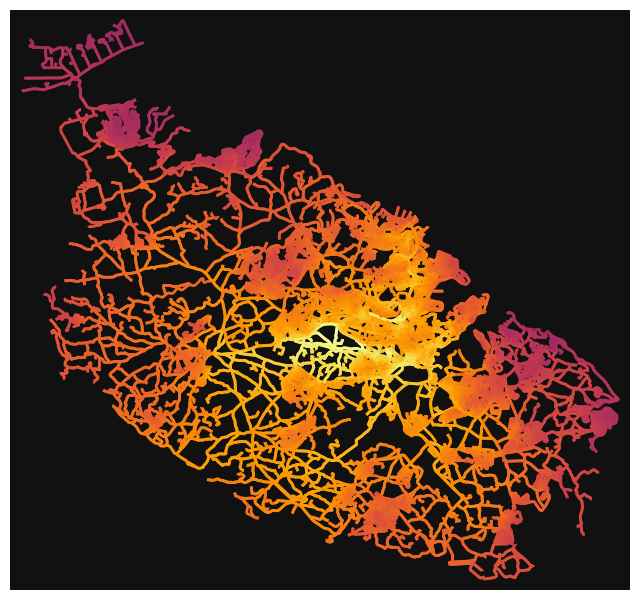

In [ ]:
# color edges in original graph with closeness centralities from line graph
ec = ox.plot.get_edge_colors_by_attr(G, "edge_centrality", cmap="inferno")
fig, ax = ox.plot.plot_graph(G, edge_color=ec, edge_linewidth=2, node_size=0)

# Routing

In [ ]:
# impute missing edge speeds and calculate edge travel times with the speed module
G = ox.routing.add_edge_speeds(G)
G = ox.routing.add_edge_travel_times(G)

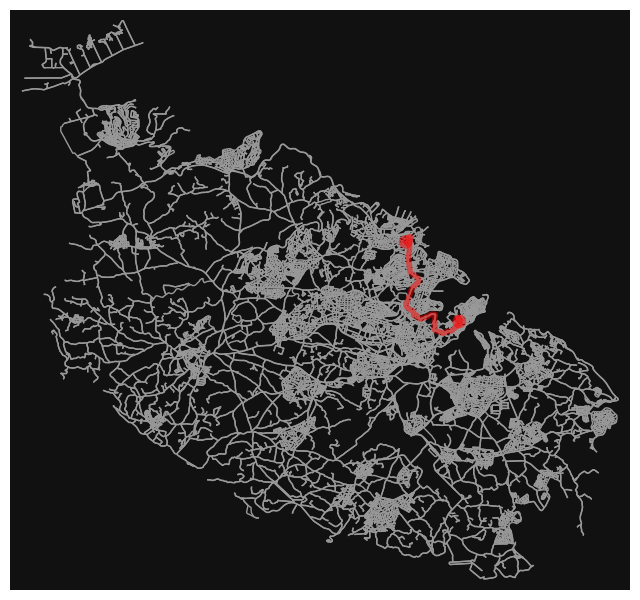

In [ ]:
# get the nearest network nodes to two lat/lng points with the distance module
orig = ox.distance.nearest_nodes(G, X=35.893385, Y=14.477465)
dest = ox.distance.nearest_nodes(G, X=35.890245, Y=14.479616)

orig = next(iter(G))
dest = list(G)[-1]

# find the shortest path between nodes, minimizing travel time, then plot it
route = ox.routing.shortest_path(G, orig, dest, weight="travel_time")
fig, ax = ox.plot.plot_graph_route(G, route, node_size=0)

In [ ]:
# how long is our route in meters?
edge_lengths = ox.routing.route_to_gdf(G, route)["length"]
round(sum(edge_lengths))

6951

In [ ]:
# how far is it between these two nodes as the crow flies?
# use OSMnx's vectorized great-circle distance (haversine) function
orig_x = G.nodes[orig]["x"]
orig_y = G.nodes[orig]["y"]
dest_x = G.nodes[dest]["x"]
dest_y = G.nodes[dest]["y"]
round(ox.distance.great_circle(orig_y, orig_x, dest_y, dest_x))

3601